**Порядок:**
```
Ячейки 1-4  : настройка окружения и данных
Ячейка 5    : Stage 1 — обучение на 1/3
Ячейка 6    : Атака на модель stage 1  ← сразу видим метрики
Ячейка 7    : Stage 2 — дообучение на 2/3
Ячейка 8    : Атака на модель stage 2
Ячейка 9    : Stage 3 — дообучение на full
Ячейка 10   : Атака на модель stage 3
Ячейка 11   : Итоговая таблица и график
```


In [24]:
# ============================================================
# ЯЧЕЙКА 1: Монтирование Drive, клонирование репозитория
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

%cd /content
!rm -rf /content/mnist-pgd
!git clone https://github.com/paofic/mnist-pgd
%cd /content/mnist-pgd

import sys
sys.path.append('/content/mnist-pgd')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
Cloning into 'mnist-pgd'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 51 (delta 26), reused 15 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 21.76 KiB | 5.44 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/mnist-pgd


In [25]:
# ============================================================
# ЯЧЕЙКА 2: Копируем исправленные файлы из Drive
# ============================================================

import shutil, os

DRIVE_SRC = '/content/drive/MyDrive/mnist-pgd-runs/src'

for fname in ['attack.py', 'utils.py']:
    src = f'{DRIVE_SRC}/{fname}'
    dst = f'/content/mnist-pgd/src/{fname}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Скопирован: {fname}')
    else:
        print(f'НЕ НАЙДЕН в Drive: {fname} — используем версию из репо')

НЕ НАЙДЕН в Drive: attack.py — используем версию из репо
НЕ НАЙДЕН в Drive: utils.py — используем версию из репо


In [26]:
# ============================================================
# ЯЧЕЙКА 3: Импорты
# ============================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from src import data, model
from src.train import train_stage
from src.attack import evaluate_targeted_pgd_attack, log_attack_results
from src.utils import set_seed

print('Импорты OK')

Импорты OK


In [41]:
# ============================================================
# ЯЧЕЙКА 4: Конфигурация и данные
# ============================================================

SEED          = 42
BATCH_SIZE    = 128
LR            = 1e-5
EPOCHS_STAGE1 = 7
EPOCHS_STAGE2 = 3
EPOCHS_STAGE3 = 3

# PGD параметры
EPS_RAW   = 5.0 / 255.0          # epsilon в масштабе [0, 1]
MNIST_STD = 0.3081
ALPHA_RAW = 1.0 / 255.0          # явно из ТЗ
EPS_MODEL   = EPS_RAW / MNIST_STD
ALPHA       = ALPHA_RAW / MNIST_STD      # шаг одной итерации
PGD_STEPS = 20
RESTARTS  = 1

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CHECKPOINT_DIR = '/content/drive/MyDrive/mnist-pgd-runs/checkpoints'
LOG_DIR        = '/content/drive/MyDrive/mnist-pgd-runs/logs'
DATA_DIR       = '/content/drive/MyDrive/mnist-pgd-runs/data'

STAGE1_CKPT = f'{CHECKPOINT_DIR}/stage1_best.pt'
STAGE2_CKPT = f'{CHECKPOINT_DIR}/stage2_best.pt'
STAGE3_CKPT = f'{CHECKPOINT_DIR}/stage3_best.pt'

STAGE1_LOG = f'{LOG_DIR}/stage1_train.json'
STAGE2_LOG = f'{LOG_DIR}/stage2_train.json'
STAGE3_LOG = f'{LOG_DIR}/stage3_train.json'
ATTACK_LOG = f'{LOG_DIR}/attack_results.json'

print('DEVICE   :', DEVICE)
print(f'EPS_MODEL: {EPS_MODEL:.6f}')
print(f'ALPHA    : {ALPHA:.6f}')

if DEVICE.type == 'cpu':
    print('\n!!! ВНИМАНИЕ: GPU не обнаружен!')
    print('Иди в Runtime → Change runtime type → T4 GPU и перезапусти!')

# ---- Данные ----
set_seed(SEED)

stage_data = data.load_mnist_stage_data(
    root=DATA_DIR, seed=SEED, download=True, eps_raw=EPS_RAW,
)

train_loader_s1 = DataLoader(
    stage_data.train_parts[0],
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True,
)
train_loader_s2 = DataLoader(
    stage_data.cumulative_parts[1],
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True,
)
train_loader_s3 = DataLoader(
    stage_data.cumulative_parts[2],
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True,
)
test_loader = DataLoader(
    stage_data.test_dataset,
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True,
)

TRAIN_SIZE_S1 = len(stage_data.train_parts[0])
TRAIN_SIZE_S2 = len(stage_data.cumulative_parts[1])
TRAIN_SIZE_S3 = len(stage_data.cumulative_parts[2])

print(f'\nStage 1 train: {TRAIN_SIZE_S1}')
print(f'Stage 2 train: {TRAIN_SIZE_S2}')
print(f'Stage 3 train: {TRAIN_SIZE_S3}')
print(f'Test:          {len(stage_data.test_dataset)}')

# Словарь для сбора результатов атак — заполняется по мере выполнения
attack_results = {}

DEVICE   : cuda
EPS_MODEL: 0.063641
ALPHA    : 0.012728

Stage 1 train: 20004
Stage 2 train: 40003
Stage 3 train: 60000
Test:          10000


In [ ]:
# ============================================================
# ЯЧЕЙКА 5: STAGE 1 — обучение на первой трети
# ============================================================

net = model.build_model(num_classes=10, pretrained=True, freeze_backbone=True).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=LR)

if os.path.exists(STAGE1_CKPT):
    print('Checkpoint stage1 найден — загружаем, обучение пропускаем.')
    ckpt = torch.load(STAGE1_CKPT, map_location=DEVICE)
    net.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    print(f"  epoch={ckpt['epoch']}, test_acc={ckpt['test_accuracy']:.4f}")
else:
    print('Checkpoint stage1 не найден — обучаем...')
    result = train_stage(
        model=net, train_loader=train_loader_s1, test_loader=test_loader,
        optimizer=optimizer, criterion=criterion, device=DEVICE,
        epochs=EPOCHS_STAGE1, checkpoint_path=STAGE1_CKPT, log_path=STAGE1_LOG,
        stage_name='stage1', stage_index=1, train_size=TRAIN_SIZE_S1, seed=SEED,
    )
    print(f"Stage 1 done. best_acc={result['best_test_accuracy']:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


Checkpoint stage1 найден — загружаем, обучение пропускаем.
  epoch=7, test_acc=0.6016


In [37]:
# ============================================================
# ЯЧЕЙКА 6: Атака на модель после stage 1
# ============================================================

print('=== Атака на модель Stage 1 ===')

ckpt = torch.load(STAGE1_CKPT, map_location=DEVICE)
net.load_state_dict(ckpt['model_state_dict'])
net.eval()

r = evaluate_targeted_pgd_attack(
    model=net, loader=test_loader,
    eps=EPS_MODEL, alpha=ALPHA, steps=PGD_STEPS,
    device=DEVICE, restarts=RESTARTS,
)
attack_results['stage1'] = r

log_attack_results(
    log_path=ATTACK_LOG, stage_name='stage1', stage_index=1,
    train_size=TRAIN_SIZE_S1, seed=SEED, attack_results=r,
)

print(f"Clean acc   : {r['clean_accuracy']:.4f}")
print(f"Adv acc     : {r['adv_accuracy']:.4f}")
print(f"Degradation : {r['degradation']:.4f}  (цель >= 0.50)")
print(f"Target hit  : {r['target_hit_rate']:.4f}")

=== Атака на модель Stage 1 ===
Clean acc   : 0.6016
Adv acc     : 0.1138
Degradation : 0.8108  (цель >= 0.50)
Target hit  : 0.8307


In [ ]:
# ============================================================
# ЯЧЕЙКА 7: STAGE 2 — дообучение на 2/3
# ============================================================

if os.path.exists(STAGE2_CKPT):
    print('Checkpoint stage2 найден — загружаем, обучение пропускаем.')
    ckpt = torch.load(STAGE2_CKPT, map_location=DEVICE)
    net.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    print(f"  epoch={ckpt['epoch']}, test_acc={ckpt['test_accuracy']:.4f}")
else:
    # Стартуем с лучших весов stage1
    ckpt = torch.load(STAGE1_CKPT, map_location=DEVICE)
    net.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])

    print('Дообучаем на 2/3 данных (stage 2)...')
    result = train_stage(
        model=net, train_loader=train_loader_s2, test_loader=test_loader,
        optimizer=optimizer, criterion=criterion, device=DEVICE,
        epochs=EPOCHS_STAGE2, checkpoint_path=STAGE2_CKPT, log_path=STAGE2_LOG,
        stage_name='stage2', stage_index=2, train_size=TRAIN_SIZE_S2, seed=SEED,
    )
    print(f"Stage 2 done. best_acc={result['best_test_accuracy']:.4f}")

Дообучаем на 2/3 данных (stage 2)...
[stage2] Epoch 1/3 | train_loss=1.4707 | train_acc=0.6460 | test_loss=1.3794 | test_acc=0.6917
[stage2] Epoch 2/3 | train_loss=1.3098 | train_acc=0.7198 | test_loss=1.2272 | test_acc=0.7489
[stage2] Epoch 3/3 | train_loss=1.1757 | train_acc=0.7633 | test_loss=1.1043 | test_acc=0.7861
Stage 2 done. best_acc=0.7861


In [29]:
# ============================================================
# ЯЧЕЙКА 8: Атака на модель после stage 2
# ============================================================

print('=== Атака на модель Stage 2 ===')

ckpt = torch.load(STAGE2_CKPT, map_location=DEVICE)
net.load_state_dict(ckpt['model_state_dict'])
net.eval()

r = evaluate_targeted_pgd_attack(
    model=net, loader=test_loader,
    eps=EPS_MODEL, alpha=ALPHA, steps=PGD_STEPS,
    device=DEVICE, restarts=RESTARTS,
)
attack_results['stage2'] = r

log_attack_results(
    log_path=ATTACK_LOG, stage_name='stage2', stage_index=2,
    train_size=TRAIN_SIZE_S2, seed=SEED, attack_results=r,
)

print(f"Clean acc   : {r['clean_accuracy']:.4f}")
print(f"Adv acc     : {r['adv_accuracy']:.4f}")
print(f"Degradation : {r['degradation']:.4f}  (цель >= 0.50)")
print(f"Target hit  : {r['target_hit_rate']:.4f}")

=== Атака на модель Stage 2 ===
Clean acc   : 0.7861
Adv acc     : 0.3367
Degradation : 0.5717  (цель >= 0.50)
Target hit  : 0.5946


In [30]:
# ============================================================
# ЯЧЕЙКА 9: STAGE 3 — дообучение на полных данных
# ============================================================

if os.path.exists(STAGE3_CKPT):
    print('Checkpoint stage3 найден — загружаем, обучение пропускаем.')
    ckpt = torch.load(STAGE3_CKPT, map_location=DEVICE)
    net.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    print(f"  epoch={ckpt['epoch']}, test_acc={ckpt['test_accuracy']:.4f}")
else:
    # Стартуем с лучших весов stage2
    ckpt = torch.load(STAGE2_CKPT, map_location=DEVICE)
    net.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])

    print('Дообучаем на всех данных (stage 3)...')
    result = train_stage(
        model=net, train_loader=train_loader_s3, test_loader=test_loader,
        optimizer=optimizer, criterion=criterion, device=DEVICE,
        epochs=EPOCHS_STAGE3, checkpoint_path=STAGE3_CKPT, log_path=STAGE3_LOG,
        stage_name='stage3', stage_index=3, train_size=TRAIN_SIZE_S3, seed=SEED,
    )
    print(f"Stage 3 done. best_acc={result['best_test_accuracy']:.4f}")

Checkpoint stage3 найден — загружаем, обучение пропускаем.
  epoch=3, test_acc=0.8557


In [20]:
PGD_STEPS = 100
RESTARTS = 5

In [21]:
# ============================================================
# ЯЧЕЙКА 10: Атака на модель после stage 3
# ============================================================

print('=== Атака на модель Stage 3 ===')

ckpt = torch.load(STAGE3_CKPT, map_location=DEVICE)
net.load_state_dict(ckpt['model_state_dict'])
net.eval()

r = evaluate_targeted_pgd_attack(
    model=net, loader=test_loader,
    eps=EPS_MODEL, alpha=ALPHA, steps=PGD_STEPS,
    device=DEVICE, restarts=RESTARTS,
)
attack_results['stage3'] = r

log_attack_results(
    log_path=ATTACK_LOG, stage_name='stage3', stage_index=3,
    train_size=TRAIN_SIZE_S3, seed=SEED, attack_results=r,
)

print(f"Clean acc   : {r['clean_accuracy']:.4f}")
print(f"Adv acc     : {r['adv_accuracy']:.4f}")
print(f"Degradation : {r['degradation']:.4f}  (цель >= 0.50)")
print(f"Target hit  : {r['target_hit_rate']:.4f}")

=== Атака на модель Stage 3 ===
Clean acc   : 0.8557
Adv acc     : 0.4457
Degradation : 0.4791  (цель >= 0.50)
Target hit  : 0.5013


In [39]:
import json

with open(ATTACK_LOG, 'r') as f:
    records = json.load(f)

# Берём последнюю запись для каждого stage
attack_results = {}
for rec in records:
    stage = rec['stage_name']
    attack_results[stage] = {
        'clean_accuracy': rec['clean_accuracy'],
        'adv_accuracy': rec['adv_accuracy'],
        'degradation': rec['degradation'],
        'target_hit_rate': rec['target_hit_rate'],
        'eps': rec['eps'],
        'alpha': rec['alpha'],
        'steps': rec['steps'],
        'restarts': rec['restarts'],
    }

print(attack_results.keys())

dict_keys(['stage1', 'stage3', 'stage2'])


Stage               Train   Clean     Adv   Degrad   TargHit
------------------------------------------------------------
Stage 1 (1/3)       20004  0.6016  0.1138   0.8108    0.8307
Stage 2 (2/3)       40003  0.7861  0.3367   0.5717    0.5946
Stage 3 (full)      60000  0.8557  0.4457   0.4791    0.5013


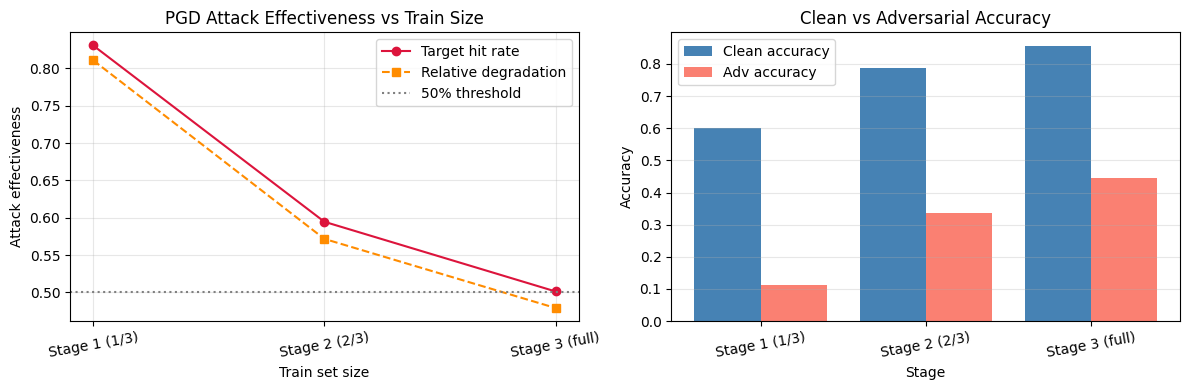

График сохранён в Drive.


In [40]:
# ============================================================
# ЯЧЕЙКА 11: Итоговая таблица + график
# ============================================================

stages_info = [
    ('Stage 1 (1/3)',  TRAIN_SIZE_S1, attack_results['stage1']),
    ('Stage 2 (2/3)',  TRAIN_SIZE_S2, attack_results['stage2']),
    ('Stage 3 (full)', TRAIN_SIZE_S3, attack_results['stage3']),
]

print(f"{'Stage':<16} {'Train':>8} {'Clean':>7} {'Adv':>7} {'Degrad':>8} {'TargHit':>9}")
print('-' * 60)
for name, size, r in stages_info:
    print(f"{name:<16} {size:>8} {r['clean_accuracy']:>7.4f} "
          f"{r['adv_accuracy']:>7.4f} {r['degradation']:>8.4f} {r['target_hit_rate']:>9.4f}")

sizes       = [s for _, s, _ in stages_info]
labels      = [n for n, _, _ in stages_info]
degradations = [r['degradation']     for _, _, r in stages_info]
target_hits  = [r['target_hit_rate'] for _, _, r in stages_info]
clean_accs   = [r['clean_accuracy']  for _, _, r in stages_info]
adv_accs     = [r['adv_accuracy']    for _, _, r in stages_info]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(sizes, target_hits,  'o-',  color='crimson',    label='Target hit rate')
ax.plot(sizes, degradations, 's--', color='darkorange', label='Relative degradation')
ax.axhline(0.5, color='gray', linestyle=':', label='50% threshold')
ax.set_xlabel('Train set size')
ax.set_ylabel('Attack effectiveness')
ax.set_title('PGD Attack Effectiveness vs Train Size')
ax.set_xticks(sizes)
ax.set_xticklabels(labels, rotation=10)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
x = range(len(stages_info))
ax.bar([i - 0.2 for i in x], clean_accs, width=0.4, label='Clean accuracy', color='steelblue')
ax.bar([i + 0.2 for i in x], adv_accs,   width=0.4, label='Adv accuracy',   color='salmon')
ax.set_xlabel('Stage')
ax.set_ylabel('Accuracy')
ax.set_title('Clean vs Adversarial Accuracy')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=10)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mnist-pgd-runs/attack_results.png', dpi=150)
plt.show()
print('График сохранён в Drive.')

In [43]:
GITHUB_USER  = "paofic"
GITHUB_TOKEN = "TOKEN"
REPO         = "mnist-pgd"

# Сначала создаём папки
!mkdir -p /content/mnist-pgd/checkpoints /content/mnist-pgd/logs

# Потом копируем файлы
!cp /content/drive/MyDrive/mnist-pgd-runs/checkpoints/stage1_best.pt /content/mnist-pgd/checkpoints/stage1_best.pt
!cp /content/drive/MyDrive/mnist-pgd-runs/checkpoints/stage2_best.pt /content/mnist-pgd/checkpoints/stage2_best.pt
!cp /content/drive/MyDrive/mnist-pgd-runs/checkpoints/stage3_best.pt /content/mnist-pgd/checkpoints/stage3_best.pt
!cp /content/drive/MyDrive/mnist-pgd-runs/logs/attack_results.json /content/mnist-pgd/logs/attack_results.json

!cd /content/mnist-pgd && git config user.email "khoba.artemiy@gmail.com"
!cd /content/mnist-pgd && git config user.name "paofic"
!cd /content/mnist-pgd && git remote set-url origin https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO}.git
!cd /content/mnist-pgd && git pull origin main --rebase
!cd /content/mnist-pgd && git add checkpoints/ logs/
!cd /content/mnist-pgd && git commit -m "add checkpoints and attack log"
!cd /content/mnist-pgd && git push

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 6 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 3.33 KiB | 1.67 MiB/s, done.
From https://github.com/paofic/mnist-pgd
 * branch            main       -> FETCH_HEAD
   b4d29a6..83e04cf  main       -> origin/main
Updating b4d29a6..83e04cf
Fast-forward
 attack_results.json |  66 ++++++++++++
 stage1_train.json   | 290 ++++++++++++++++++++++++++++++++++++++++++++++++++++
 stage2_train.json   |  66 ++++++++++++
 stage3_train.json   | 114 +++++++++++++++++++++
 4 files changed, 536 insertions(+)
 create mode 100644 attack_results.json
 create mode 100644 stage1_train.json
 create mode 100644 stage2_train.json
 create mode 100644 stage3_train.json
[main 4de3bbb] add checkpoints and attack log
 4 files changed, 66 insertions(+)
 create mode 100644 checkpoints/stage1_best.pt
 create mode 100644 checkpoints/stage2_be

In [46]:
GITHUB_USER  = "paofic"
GITHUB_TOKEN = "TOKEN"
REPO         = "mnist-pgd"

# Создаём папки
!mkdir -p /content/mnist-pgd/checkpoints /content/mnist-pgd/logs

# Копируем checkpoints
!cp /content/drive/MyDrive/mnist-pgd-runs/checkpoints/stage1_best.pt /content/mnist-pgd/checkpoints/stage1_best.pt
!cp /content/drive/MyDrive/mnist-pgd-runs/checkpoints/stage2_best.pt /content/mnist-pgd/checkpoints/stage2_best.pt
!cp /content/drive/MyDrive/mnist-pgd-runs/checkpoints/stage3_best.pt /content/mnist-pgd/checkpoints/stage3_best.pt

# Копируем логи
!cp /content/drive/MyDrive/mnist-pgd-runs/logs/attack_results.json /content/mnist-pgd/logs/attack_results.json


# Git настройка
!cd /content/mnist-pgd && git config user.email "khoba.artemiy@gmail.com"
!cd /content/mnist-pgd && git config user.name "paofic"
!cd /content/mnist-pgd && git remote set-url origin https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO}.git

# Pull чтобы синхронизироваться с GitHub
!cd /content/mnist-pgd && git pull origin main --rebase

# Добавляем всё и пушим
!cd /content/mnist-pgd && git add checkpoints/ logs/
!cd /content/mnist-pgd && git commit -m "add checkpoints, logs"
!cd /content/mnist-pgd && git push

From https://github.com/paofic/mnist-pgd
 * branch            main       -> FETCH_HEAD
Already up to date.
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
